# Scenario 2 — 170 km / 186 GBaud (double band)

Full performance-vs-complexity figure: received SNR (peak over power) vs
complexity [RM/2D] for **EDC, Ideal DBP, OSSFM, LDBP, ESSFM, L-ESSFM**, at the
two oversamplings **n=1.125 (solid)** and **n=2 (dashed)**.

Models are loaded from `results/<scenario>/` (trained for this scenario).
The simulation runs on the shared forward.

NOTE: evaluating all curves loads the 2 GB forward and runs many backprops; in a
notebook it's fine cell-by-cell. Each method is computed independently below.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import sys, os
_ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, os.path.join(_ROOT, 'core')); os.chdir(_ROOT)
import numpy as np
import matplotlib.pyplot as plt
from system import build_system
from backprop import curve
from complexity import eval_compl, eval_compl_time, complexity_ldbp

SCENARIO = 'scenario_170km_186GBd'
RESDIR   = f'results/{SCENARIO}'
L_KM, R_GBD = 170e3, 186e9
N2CFG = f'config/{SCENARIO}_n2.ini'
if not os.path.exists(N2CFG):
    import re
    _s = open(f'config/{SCENARIO}.ini').read()
    _s = re.sub(r'(?m)^digital oversampling = .*','digital oversampling = 2', _s)
    open(N2CFG,'w').write(_s)
CFG  = {1.125: f'config/{SCENARIO}.ini', 2.0: N2CFG}
NS_FULL = [1,3,5,7,10,20,30,40,50,100,200]   # n=1.125
NS_RED  = [1,5,10,20,30,40,50,100,200]                 # n=2 (reduced)

# RETRAIN: if a method's parameters.csv is missing (or RETRAIN=True), the helpers
# below TRAIN it from scratch with the PyTorch trainer (core/train.py, dual-pol)
# and save it under RESDIR. With RETRAIN=False and the coefficients present, the
# notebook just loads them and simulates (fast, no GPU training).
RETRAIN = False

# fast training config (Gaussian, short 1024-sym blocks) derived from the scenario
def _train_cfg(nos):
    import re
    base = CFG[nos]
    out = f'config/_train_{SCENARIO}_n{"2" if nos==2.0 else "1125"}.ini'
    s = open(base).read()
    s = s.replace('data symbols per block = 262144', 'data symbols per block = 1024')
    s = re.sub(r'(?m)^modulation = .*', 'modulation = Gaussian', s)
    open(out, 'w').write(s); return out

## 1. Load the shared forward

In [2]:
# Forward for this scenario: local copy under l_essfm/forward/ (loaded ONCE, reused).
FWD_PATH = f'forward/forward_{SCENARIO}.npy'
fwd = np.load(FWD_PATH, allow_pickle=True).item()
data = {round(10*np.log10(Pw/1e-3), 4): [(np.array(y), np.array(x)) for (y, x) in r] for Pw, r in fwd.items()}
Pgrid = np.array(sorted(data))
print(f'{len(Pgrid)} powers loaded from {FWD_PATH}')


20 powers loaded from forward/forward_scenario_170km_186GBd.npy


## 2. Helpers: peak SNR for a method at given Ns and oversampling

In [3]:
def peak(nos, kind, ns, params=None, edc=False):
    S = build_system(CFG[nos])
    return curve(S, data, Pgrid, kind, ns, params, edc=edc).max()

def lessfm_peak(nos, tag, ns):
    """Peak SNR for L-ESSFM/ESSFM at (nos, ns). Loads parameters.csv if present;
    if missing (or RETRAIN), trains it with the PyTorch dual-pol trainer and saves.
    NOTE (scenarios 01/02 only): ESSFM is trained with opt_rho=True (optimized
    splitting ratio), as Dario wants ESSFM here to keep its rho-optimized form.
    Scenario 03 uses the paper definition (rho=0.5 fixed, train_essfm default)."""
    suff = '' if nos == 1.125 else '_n2'
    p = f'{RESDIR}/{tag}{suff}_Ns{ns}/parameters.csv'
    if RETRAIN or not os.path.exists(p):
        from train import train_lessfm, train_essfm
        Strain = build_system(_train_cfg(nos))
        print(f'  training {tag} n={nos} Ns={ns} ...', flush=True)
        if tag == 'essfm':
            train_essfm(Strain, ns, p, opt_rho=True)   # 01/02: optimized rho
        else:
            train_lessfm(Strain, ns, p)
    return peak(nos, 'lessfm', ns, p)

## 3. References: EDC, Ideal DBP (both n)

In [4]:
# Ideal DBP: backprop processes ONE channel (narrow band) so few steps suffice.
# 170km/93GBd -> 100 steps/span (converged). EDC = 1 dispersion step, n-independent.
edc      = peak(1.125, 'edc', 1, edc=True)            # EDC: same SNR at both n
ideal125 = peak(1.125, 'ideal', 400)
ideal2   = peak(2.0,   'ideal', 400)
print(f'EDC {edc:.3f} dB | Ideal n=1.125 DBP {ideal125:.3f} dB | Ideal n=2 DBP {ideal2:.3f} dB')


EDC 17.523 dB | Ideal n=1.125 DBP 18.665 dB | Ideal n=2 DBP 19.014 dB


## 4. L-ESSFM and ESSFM, both oversamplings

In [5]:
lessfm125 = {ns: lessfm_peak(1.125,'lessfm',ns) for ns in NS_FULL}
lessfm125 = {k:v for k,v in lessfm125.items() if v is not None}
essfm125  = {ns: lessfm_peak(1.125,'essfm', ns) for ns in NS_FULL}
essfm125  = {k:v for k,v in essfm125.items() if v is not None}
lessfm2   = {ns: lessfm_peak(2.0,'lessfm',ns) for ns in NS_RED}
lessfm2   = {k:v for k,v in lessfm2.items() if v is not None}
essfm2    = {ns: lessfm_peak(2.0,'essfm', ns) for ns in NS_RED}
essfm2    = {k:v for k,v in essfm2.items() if v is not None}
print('L-ESSFM n=1.125:', {k:round(v,3) for k,v in lessfm125.items()})
print('L-ESSFM n=2   :', {k:round(v,3) for k,v in lessfm2.items()})


L-ESSFM n=1.125: {1: np.float64(17.99), 3: np.float64(18.295), 5: np.float64(18.434), 7: np.float64(18.473), 10: np.float64(18.577), 20: np.float64(18.691), 30: np.float64(18.747), 40: np.float64(18.773), 50: np.float64(18.803), 100: np.float64(18.817), 200: np.float64(18.821)}
L-ESSFM n=2   : {1: np.float64(17.997), 5: np.float64(18.453), 10: np.float64(18.626), 20: np.float64(18.791), 30: np.float64(18.862), 40: np.float64(18.94), 50: np.float64(18.979), 100: np.float64(19.008), 200: np.float64(19.007)}


## 5. OSSFM (both n) and LDBP (n=2, pruning sweep)

In [6]:
from system import make_bw
ossfm125 = {ns: peak(1.125, 'ossfm', ns) for ns in NS_RED}
ossfm125 = {k:v for k,v in ossfm125.items() if v is not None}
ossfm2 = {ns: peak(2.0, 'ossfm', ns) for ns in NS_RED}
ossfm2 = {k:v for k,v in ossfm2.items() if v is not None}
print('OSSFM n=1.125:', {k:round(v,3) for k,v in ossfm125.items()})
print('OSSFM n=2   :', {k:round(v,3) for k,v in ossfm2.items()})

def _ldbp_cfg(logarithmic=True):
    import re
    s = open(CFG[2.0]).read()
    s = s.replace('data symbols per block = 262144', 'data symbols per block = 1024')
    s = re.sub(r'(?m)^modulation = .*', 'modulation = Gaussian', s)
    if logarithmic:
        s = re.sub(r'(?m)^step size method = .*', 'step size method = logarithmic', s)
    out = 'config/_ldbp_train.ini'; open(out, 'w').write(s); return out

def _ldbp_cfg_eval(logarithmic=True):
    import re
    s = open(CFG[2.0]).read()
    s = re.sub(r'(?m)^modulation = .*', 'modulation = Gaussian', s)
    if logarithmic:
        s = re.sub(r'(?m)^step size method = .*', 'step size method = logarithmic', s)
    out = 'config/_ldbp_eval.ini'; open(out, 'w').write(s); return out

from ldbp_eval import load_ldbp_params, ldbp_backprop
S_eval = build_system(_ldbp_cfg_eval())          
bw_eval = make_bw(S_eval, 200)

def ldbp_peak(tag, target):
    """target: per-step tap PATTERN (e.g. [17] uniform or [11,9] sawtooth), tiled."""
    p = f'{RESDIR}/ldbp_{tag}/parameters.csv'
    if RETRAIN or not os.path.exists(p):
        from train import train_ldbp
        Strain = build_system(_ldbp_cfg())   # uses 1024 for training (correct)
        M = make_bw(Strain, 200).model_steps
        print(f'  training LDBP {tag} (init 21 -> {target}, log step) ...', flush=True)
        train_ldbp(Strain, 200, p, [21]*M, iters=20000, P_dbm=10.0, lr=1e-3,
                   target_taps=target, n_blocks=200)
    cd, nl = load_ldbp_params(p, bw_eval.model_steps)
    snr = [np.mean([ldbp_backprop(S_eval, bw_eval, cd, nl, np.array(y), np.array(x), 10**(pp/10)*1e-3)
                    for (y, x) in data[pp]]) for pp in Pgrid]
    return max(snr)

# the 5 Fig.1b LDBP points: (tag, target pattern, average taps for complexity)
LDBP_POINTS = [('prune19',[19],19), ('p17',[17],17), ('p15',[15],15), ('p13',[13],13)]
ldbp = []
for tag, target, avg in LDBP_POINTS:
    if RETRAIN or os.path.exists(f'{RESDIR}/ldbp_{tag}/parameters.csv'):
        s = ldbp_peak(tag, target); nc = (avg - 1) / 2
        ldbp.append((complexity_ldbp(200, nc, 2), s))
ldbp.sort()
print('LDBP points:', [(round(c), round(s,3)) for c, s in ldbp])



OSSFM n=1.125: {1: np.float64(17.524), 5: np.float64(17.57), 10: np.float64(17.628), 20: np.float64(17.718), 30: np.float64(17.802), 40: np.float64(17.879), 50: np.float64(17.959), 100: np.float64(18.326), 200: np.float64(18.699)}
OSSFM n=2   : {1: np.float64(17.524), 5: np.float64(17.587), 10: np.float64(17.662), 20: np.float64(17.789), 30: np.float64(17.899), 40: np.float64(18.027), 50: np.float64(18.145), 100: np.float64(18.611), 200: np.float64(19.013)}
LDBP points: [(9406, np.float64(18.064)), (10606, np.float64(18.335)), (11806, np.float64(18.728)), (13006, np.float64(18.85))]


## 6. The full Fig. 1b

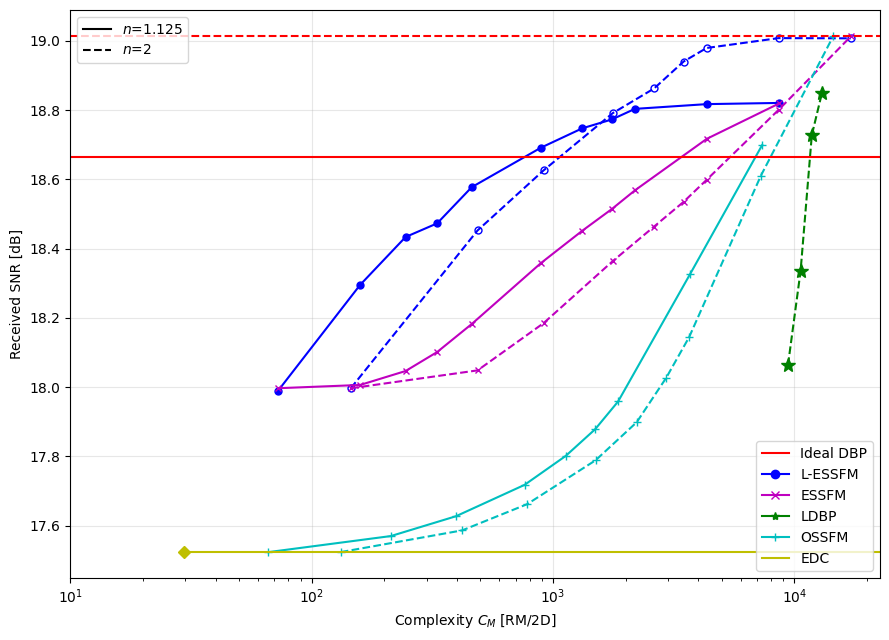

In [7]:
C = {'lessfm':'b','essfm':'m','ossfm':'c','ldbp':'g','edc':'y','ideal':'r'}
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['font.size'] = 16
plt.rcParams['lines.markersize'] = 9
fig, ax = plt.subplots(figsize=(8,6))
def cx(d, nos): return [eval_compl(n, nos, L_KM, R_GBD) for n in sorted(d)], [d[n] for n in sorted(d)]
# Each method is costed with its CHEAPEST implementation: time-domain cost grows
# with Nc, frequency-domain cost depends only on the FFT block (Nc-independent).
# ESSFM/L-ESSFM (large Nc) -> frequency; OSSFM (single coefficient, Nc=0) ->
# time (complexityRM_OSSFM_time in Stella's MATLAB), ~14% cheaper.
def cxt(d, nos): return [eval_compl_time(n, nos, L_KM, R_GBD, 0) for n in sorted(d)], [d[n] for n in sorted(d)]
# L-ESSFM
x,y = cx(lessfm125,1.125); ax.plot(x,y,color=C['lessfm'],ls='-',marker='o',ms=6)
if lessfm2: x,y=cx(lessfm2,2.0); ax.plot(x,y,color=C['lessfm'],ls='--',marker='o',mfc='none',ms=6)
# ESSFM
x,y = cx(essfm125,1.125); ax.plot(x,y,color=C['essfm'],ls='-',marker='x',ms=8)
if essfm2: x,y=cx(essfm2,2.0); ax.plot(x,y,color=C['essfm'],ls='--',marker='x',ms=8)
# OSSFM
x,y = cxt(ossfm125,1.125); ax.plot(x,y,color=C['ossfm'],ls='-',marker='+',ms=9)
x,y = cxt(ossfm2,2.0); ax.plot(x,y,color=C['ossfm'],ls='--',marker='+',ms=9)
# LDBP (n=2)
if ldbp: ax.plot([c for c,_ in ldbp],[s for _,s in ldbp],color=C['ldbp'],ls='--',marker='*',ms=12)
# Ideal + EDC
ax.axhline(ideal125,color=C['ideal'],ls='-'); ax.axhline(ideal2,color=C['ideal'],ls='--')
ax.set_xscale('log'); ax.set_xlim(1e1, ax.get_xlim()[1])
x0 = eval_compl(0,1.125,L_KM,R_GBD)
ax.plot([x0, ax.get_xlim()[1]],[edc,edc],color=C['edc'],ls='-'); ax.plot([x0],[edc],color=C['edc'],marker='D',ms=9)
from matplotlib.lines import Line2D
meth=[Line2D([0],[0],color=C['ideal'],label='Ideal DBP'),Line2D([0],[0],color=C['lessfm'],marker='o',label='L-ESSFM'),
      Line2D([0],[0],color=C['essfm'],marker='x',label='ESSFM'),Line2D([0],[0],color=C['ldbp'],marker='*',label='LDBP'),
      Line2D([0],[0],color=C['ossfm'],marker='+',label='OSSFM'),Line2D([0],[0],color=C['edc'],label='EDC')]
sty=[Line2D([0],[0],color='k',ls='-',label='$n$ = 1.125'),Line2D([0],[0],color='k',ls='--',label='$n$ = 2')]
l1=ax.legend(handles=meth,loc='lower right',fontsize=13); ax.add_artist(l1); ax.legend(handles=sty,loc='upper left',fontsize=13)
ax.set_xlabel('Complexity $C_M$ [RM/2D]'); ax.set_ylabel('Received SNR [dB]'); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig(f'{RESDIR}/fig1b.png',dpi=110); plt.savefig(f'{RESDIR}/fig1b.svg'); plt.show()

## 7. Same figure vs number of steps $N_s$

Identical layout, but the x-axis is the number of DBP steps $N_s$ instead of the
complexity. EDC (no DBP steps) and Ideal DBP are horizontal references. LDBP is
shown at its best point (full taps) at $N_s$=200.

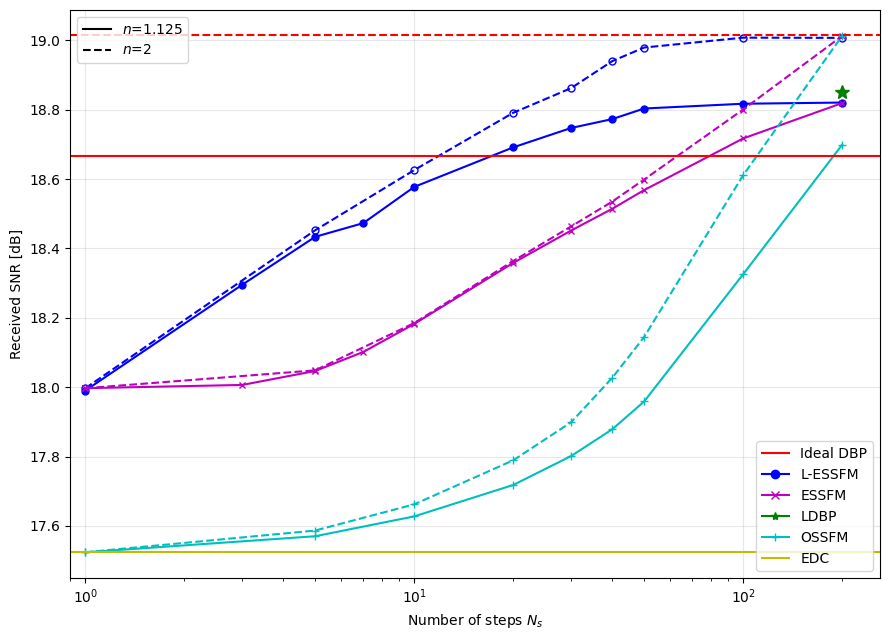

In [8]:
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['font.size'] = 16
plt.rcParams['lines.markersize'] = 9
fig, ax = plt.subplots(figsize=(8,6))
# x-axis = number of steps Ns (the dict keys); same colours/markers as Fig.1b
def nx(d): return sorted(d), [d[n] for n in sorted(d)]
# L-ESSFM
x,y = nx(lessfm125); ax.plot(x,y,color=C['lessfm'],ls='-',marker='o',ms=6)
if lessfm2: x,y=nx(lessfm2); ax.plot(x,y,color=C['lessfm'],ls='--',marker='o',mfc='none',ms=6)
# ESSFM
x,y = nx(essfm125); ax.plot(x,y,color=C['essfm'],ls='-',marker='x',ms=8)
if essfm2: x,y=nx(essfm2); ax.plot(x,y,color=C['essfm'],ls='--',marker='x',ms=8)
# OSSFM
x,y = nx(ossfm125); ax.plot(x,y,color=C['ossfm'],ls='-',marker='+',ms=9)
x,y = nx(ossfm2); ax.plot(x,y,color=C['ossfm'],ls='--',marker='+',ms=9)
# LDBP (n=2): single best point (full taps) at Ns=200
if ldbp: ax.plot([200],[max(s for _,s in ldbp)],color=C['ldbp'],ls='none',marker='*',ms=12)
# Ideal + EDC: horizontal references (EDC now also horizontal, no DBP steps)
ax.axhline(ideal125,color=C['ideal'],ls='-'); ax.axhline(ideal2,color=C['ideal'],ls='--')
ax.axhline(edc,color=C['edc'],ls='-')
ax.set_xscale('log'); ax.set_xlim(9e-1, ax.get_xlim()[1])
from matplotlib.lines import Line2D
meth=[Line2D([0],[0],color=C['ideal'],label='Ideal DBP'),Line2D([0],[0],color=C['lessfm'],marker='o',label='L-ESSFM'),
      Line2D([0],[0],color=C['essfm'],marker='x',label='ESSFM'),Line2D([0],[0],color=C['ldbp'],marker='*',label='LDBP'),
      Line2D([0],[0],color=C['ossfm'],marker='+',label='OSSFM'),Line2D([0],[0],color=C['edc'],label='EDC')]
sty=[Line2D([0],[0],color='k',ls='-',label='$n$ = 1.125'),Line2D([0],[0],color='k',ls='--',label='$n$ = 2')]
l1=ax.legend(handles=meth,loc='lower right',fontsize=13); ax.add_artist(l1); ax.legend(handles=sty,loc='upper left',fontsize=13)
ax.set_xlabel('Number of steps $N_s$'); ax.set_ylabel('Received SNR [dB]'); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig(f'{RESDIR}/fig_vs_steps.png',dpi=110); plt.savefig(f'{RESDIR}/fig_vs_steps.svg'); plt.show()